In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import fock_dm, wigner

import h5py

In [14]:
from scipy.fft import fft, fftshift, fftfreq
from scipy.signal import hilbert
import matplotlib.gridspec as gridspec

def chronocyclic_wigner_padding(E_t, t, n_padding=10, plot_idx=0):
    N = len(t)
    dt = (t[1] - t[0])
    print(f"N = {N}, dt = {dt:.3e} s")

    N_pad = N * n_padding
    omega = np.fft.fftshift(np.fft.fftfreq(N_pad, dt)) * 2 * np.pi
    print(f"N_fft = {N_pad}, omega[0]={omega[0]:.3e}, omega[-1]={omega[-1]:.3e}, domega = {omega[1] - omega[0]:.3e}")

    W = np.zeros((N, N_pad), dtype=complex)
    tau_range = np.arange(-N//2, N//2) * dt
    dtau = tau_range[1] - tau_range[0]
    print(f"tau_range: {tau_range[0]:.3e} ... {tau_range[-1]:.3e}, dtau = {dtau:.3e}")

    print("∫|E(t)|² dt =", np.trapezoid(np.abs(E_t)**2, t))
    for i, ti in enumerate(t):
        Et_plus = np.interp(ti + tau_range/2, t, E_t, left=0, right=0)
        Et_minus = np.interp(ti - tau_range/2, t, np.conj(E_t), left=0, right=0)
        product = Et_plus * Et_minus

        pad_total = N_pad - N
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        product_padded = np.pad(product, (pad_left, pad_right), mode='constant')

        product_padded_shifted = np.fft.ifftshift(product_padded)
        W_fft = np.fft.fftshift(np.fft.fft(product_padded_shifted)) * dt / (2 * np.pi)
        W[i, :] = W_fft

        if plot_idx is not None and i == plot_idx:
            print(f"--- t[{i}] = {ti:.3e} ---")
            plt.figure(figsize=(6,4))
            plt.plot(t*1e9, np.real(Et_plus*Et_minus), label='Re(product)')
            plt.legend()
            plt.xlabel("Time [ns]")
            plt.show()

            plt.figure(figsize=(6,4))
            plt.plot(omega/(2*np.pi)*1e-9, np.real(W_fft), label='Re[W(t, ω)]')
            plt.plot(omega/(2*np.pi)*1e-9, np.imag(W_fft), label='Im[W(t, ω)]', linestyle='--')
            plt.plot(omega/(2*np.pi)*1e-9, np.abs(W_fft), label='|W(t, ω)|', linewidth=2, alpha=0.6)
            plt.xlabel("Frequency [GHz]")
            plt.ylabel("Amplitude")
            plt.title(f"Wigner FFT result at t = {ti*1e9:.1f} ns")
            plt.xlim(-0.02, 0.02)
            plt.legend()
            plt.grid()
            plt.show()

            print("FFT max:", np.max(np.abs(W_fft)))
            print("FFT sum:", np.sum(np.real(W_fft)) * (omega[1]-omega[0]))   

    total_energy = np.sum(np.real(W)) * (omega[1]-omega[0]) * dt
    print("=== Total integrated energy of Wigner function ===")
    print(total_energy)

    return np.real(W), omega

def energy_width(x, intensity, fraction=0.99):
    intensity = np.abs(intensity)**2
    intensity /= np.trapezoid(intensity, x)
    cumsum = np.cumsum(intensity)
    cumsum /= cumsum[-1]

    lower_idx = np.argmax(cumsum > (1 - fraction) / 2)
    upper_idx = np.argmax(cumsum >= 1 - (1 - fraction) / 2)
    width = x[upper_idx] - x[lower_idx]
    return width

In [15]:
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0
=== Total integrated energy of Wigner function ===
1.0000000000003018
Δt=296.00 ns, Δf=0.00700 GHz, TBP=2.07096

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0
=== Total integrated energy of Wigner function ===
1.0000000000003018
Δt=388.00 ns, Δf=0.00900 GHz, TBP=3.49025

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0000000000000002
=== Total integrated energy of Wigner function ===
1.0000000000003022
Δt=458.00 ns, Δf=0.01099 GHz, TBP=5.03548

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e

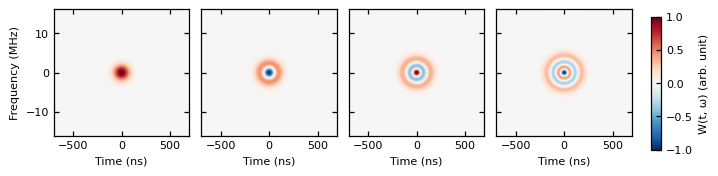

In [16]:
from scipy.special import gamma, zeta, eval_hermite, factorial
from matplotlib.cm import ScalarMappable
def hermite(x, n, kappa):
    x_scaled = np.sqrt(kappa) * x
    norm = np.sqrt(np.sqrt(kappa / np.pi)) / np.sqrt(2**n * factorial(n))
    psi = norm * eval_hermite(n, x_scaled) * np.exp(-x_scaled**2 / 2)
    return np.asarray(psi, dtype=np.float64) 

t_ns = np.linspace(-1000, 1000, 2001)
t = t_ns*1e-9
modes = [0, 1, 2, 3]
freq_max = 16e6
time_max = 700*1e-9
n_padding = 40
kappa_her = 12e-6*2*np.pi*2

results = []
for m in modes:
    E_t = hermite(t_ns, m, kappa_her)
    E_t /= np.sqrt(np.trapezoid(np.abs(E_t)**2, t))

    W, omega = chronocyclic_wigner_padding(E_t, t, n_padding, None)
    normalization = np.trapezoid(np.trapezoid(W, omega, axis=1), t)
    
    mask_f = np.abs(omega/(2*np.pi)) < freq_max
    omega_crop = omega[mask_f]
    W_crop_f = W[:, mask_f]
    mask_t = np.abs(t) < time_max
    time_crop = t[mask_t]
    W_crop = W_crop_f[mask_t, :]

    dt = t[1] - t[0]
    freq = fftshift(fftfreq(len(t), dt))
    E_f = fftshift(fft(E_t))
    delta_t = energy_width(t, E_t, fraction=0.99)
    delta_f = energy_width(freq, E_f, fraction=0.99)

    print(f"Δt={delta_t*1e9:.2f} ns, Δf={delta_f*1e-9:.5f} GHz, TBP={delta_t*delta_f:.5f}\n")

    results.append((m, time_crop, omega_crop, W_crop, delta_t, delta_f))

W_max_abs = max(np.max(np.abs(W_crop)) for _, _, _, W_crop, _, _ in results)

fig, axes = plt.subplots(1, 4, figsize=(6.8, 1.9), sharey=True)
cmap = 'RdBu_r'

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results):
    W_norm = W_crop / W_max_abs
    im = axes[idx].pcolormesh(
        time_crop*1e9, omega_crop*1e-6/(2*np.pi), W_norm.T,
         cmap=cmap, vmin=-1, vmax=1, rasterized=True
    )
    axes[idx].set_xlabel("Time (ns)")
    if idx == 0:
        axes[idx].set_ylabel("Frequency (MHz)")
    # axes[idx].set_title(f"Mode {m}")

plt.tight_layout(rect=[0, 0, 0.95, 0.95])

sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
cbar_ax = fig.add_axes([0.96, 0.15, 0.015, 0.7])
fig.colorbar(sm, cax=cbar_ax, label="W(t, ω) (arb. unit)")
# plt.savefig('Figapp3_e1.pdf', dpi=300, bbox_inches='tight')
plt.show()


# fig3d = plt.figure(figsize=(8, 8))  # smaller overall size
# gs = gridspec.GridSpec(2, 2, figure=fig3d, wspace=0.2, hspace=0.3)
# axes3d = [fig3d.add_subplot(gs[i, j], projection="3d") for i in range(2) for j in range(2)]


# for idx, (ax, (m, time_crop, omega_crop, W_crop, _, _)) in enumerate(zip(axes3d, results)):
#     W_norm = W_crop / W_max_abs

#     T, Wm = np.meshgrid(time_crop*1e9, omega_crop*1e-9/(2*np.pi))
#     surf = ax.plot_surface(
#         T, Wm, W_norm.T,
#         cmap=cmap, linewidth=0, antialiased=True, vmin=-1, vmax=1
#     )
#     ax.set_xlabel("Time (ns)", labelpad=6)
#     ax.set_ylabel("Frequency (GHz)", labelpad=6)
#     ax.set_zlabel("W(t, ω)", labelpad=8)
#     ax.set_title(f"Mode m={m}", pad=10)
#     ax.view_init(elev=30, azim=-60)
#     ax.set_box_aspect((1, 1, 0.7))  # flatten z-axis a bit for compactness

# sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
# cbar_ax = fig3d.add_axes([1, 0.15, 0.02, 0.7])
# fig3d.colorbar(sm, cax=cbar_ax, label="W(t, ω) (arb. unit)")

# plt.tight_layout(rect=[0, 0, 0.9, 0.95])
# plt.show()

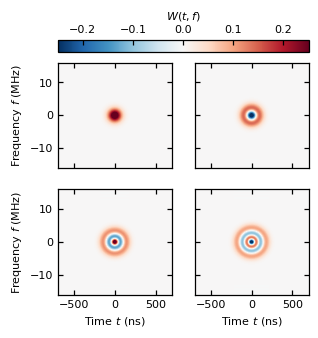

In [ ]:

cmap = 'RdBu_r'
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(5, 7))
gs = GridSpec(4, 3, height_ratios=[1,1, 1,1], hspace=0.2)
axes_top = [[fig.add_subplot(gs[row, col]) for col in range(2)] for row in range(2)]

vmin=-0.25
vmax=0.25

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results):
    row = idx // 2
    col = idx % 2
    W_norm = W_crop #/ W_max_abs
    omega_MHz = omega_crop*1e-6/(2*np.pi)

    axes_top[row][col].pcolormesh(
        time_crop*1e9, omega_MHz, W_norm.T,
        cmap='RdBu_r', vmin=vmin, vmax=vmax, shading="auto",
        rasterized=True
    )
    axes_top[row][col].set_xticks([-500, 0, 500])
    axes_top[row][col].set_yticks([ -10,  0, 10])
    if idx in [0,2]:
        axes_top[row][col].set_ylabel(r"Frequency $f$ (MHz)")
    else:
        axes_top[row][col].tick_params(labelleft=False)
    if idx in [2,3]:
        axes_top[row][col].set_xlabel(r"Time $t$ (ns)")
    else:
        axes_top[row][col].tick_params(labelbottom=False)
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=fig.axes, 
    location='top',
    fraction=0.06, pad=0.04, orientation='horizontal'
)
cbar.set_label("$W(t, f)$")

for ax in fig.axes:
    for im in ax.get_images():
        im.set_rasterized(True)

# plt.savefig('Fig10.pdf', dpi=300, bbox_inches='tight')
plt.show()